# Раздел 1. Моделирование геометрической вероятности

### Задача о встрече в кафе

> Два друга, Анна и Борис, договорились встретиться в кафе в промежутке времени с 18:00 до 19:00. Каждый из них приходит в случайный момент времени в этот час и ждёт другого **15 минут**, после чего уходит, если встреча не состоялась. Найти вероятность того, что друзья встретятся.

#### Теоретическое решение

Пусть $x$ — момент прихода Анны (в минутах от 18:00), $y$ — момент прихода Бориса.
Тогда пространство элементарных исходов — квадрат:
$$\Omega = \{(x, y) : 0 \leq x \leq 60, \; 0 \leq y \leq 60\}$$
Площадь этого квадрата:
$$S_{\Omega} = 60 \cdot 60 = 3600$$
Друзья встретятся, если разница во времени их прихода не превышает 15 минут:
$$|x - y| \leq 15$$
Эта область ограничена прямыми $y = x + 15$ и $y = x - 15$.
Площадь области, где встреча **не** состоится (два треугольника по углам квадрата со стороной $60 - 15 = 45$):
$$S_{\text{не встретились}} = 2 \cdot \frac{45^2}{2} = 45^2 = 2025$$
Площадь благоприятной области:
$$S_A = S_{\Omega} - S_{\text{не встретились}} = 3600 - 2025 = 1575$$
Искомая вероятность:
$$P(A) = \frac{S_A}{S_{\Omega}} = \frac{1575}{3600} = \frac{7}{16} = 0{,}4375$$

In [1]:
S_omega = 60 * 60
S_no_meet = 45 ** 2
S_A = S_omega - S_no_meet
P = S_A / S_omega

print(f"Площадь квадрата Ω: {S_omega}")
print(f"Площадь области 'не встретились': {S_no_meet}")
print(f"Площадь благоприятной области: {S_A}")
print(f"Теоретическая вероятность встречи: {P} = 7/16")

Площадь квадрата Ω: 3600
Площадь области 'не встретились': 2025
Площадь благоприятной области: 1575
Теоретическая вероятность встречи: 0.4375 = 7/16


#### Моделирование методом Монте-Карло

Сгенерируем $N = 100\,000$ случайных пар моментов прихода $(x, y)$ и подсчитаем долю случаев, когда $|x - y| \leq 15$.

In [2]:
import numpy as np

N = 100_000
np.random.seed(42)

x = np.random.uniform(0, 60, N)
y = np.random.uniform(0, 60, N)

meet = np.abs(x - y) <= 15
P_sim = meet.sum() / N

print(f"Количество испытаний: {N}")
print(f"Количество встреч: {meet.sum()}")
print(f"Симулированная вероятность: {P_sim:.4f}")
print(f"Теоретическая вероятность:  {P:.4f}")
print(f"Разница: {abs(P_sim - P):.4f}")

Количество испытаний: 100000
Количество встреч: 43925
Симулированная вероятность: 0.4392
Теоретическая вероятность:  0.4375
Разница: 0.0017


#### Графическая иллюстрация

Зелёная область — благоприятные исходы (встреча состоялась), серая — встреча не состоялась.

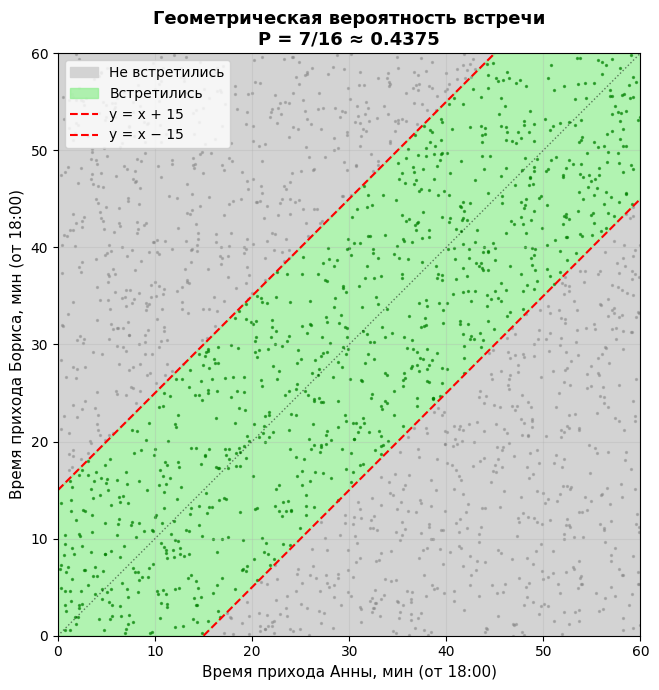

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

# Серая область — не встретились (два треугольника)
tri1 = plt.Polygon([(0, 15), (0, 60), (45, 60)], color='lightgray', label='Не встретились')
tri2 = plt.Polygon([(15, 0), (60, 0), (60, 45)], color='lightgray')
ax.add_patch(tri1)
ax.add_patch(tri2)

# Зелёная область — встретились
meet_area = plt.Polygon(
    [(0, 0), (15, 0), (60, 45), (60, 60), (45, 60), (0, 15)],
    color='lightgreen', alpha=0.7, label='Встретились'
)
ax.add_patch(meet_area)

# Границы и линии y = x ± 15
ax.plot([0, 45], [15, 60], 'r--', linewidth=1.5, label='y = x + 15')
ax.plot([15, 60], [0, 45], 'r--', linewidth=1.5, label='y = x − 15')
ax.plot([0, 60], [0, 60], 'k:', linewidth=1, alpha=0.5)

# Точки симуляции (первые 2000 для наглядности)
ax.scatter(x[:2000][~meet[:2000]], y[:2000][~meet[:2000]],
           c='gray', s=2, alpha=0.4)
ax.scatter(x[:2000][meet[:2000]], y[:2000][meet[:2000]],
           c='green', s=2, alpha=0.6)

ax.set_xlim(0, 60)
ax.set_ylim(0, 60)
ax.set_xlabel('Время прихода Анны, мин (от 18:00)', fontsize=11)
ax.set_ylabel('Время прихода Бориса, мин (от 18:00)', fontsize=11)
ax.set_title(f'Геометрическая вероятность встречи\nP = 7/16 ≈ {P:.4f}',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

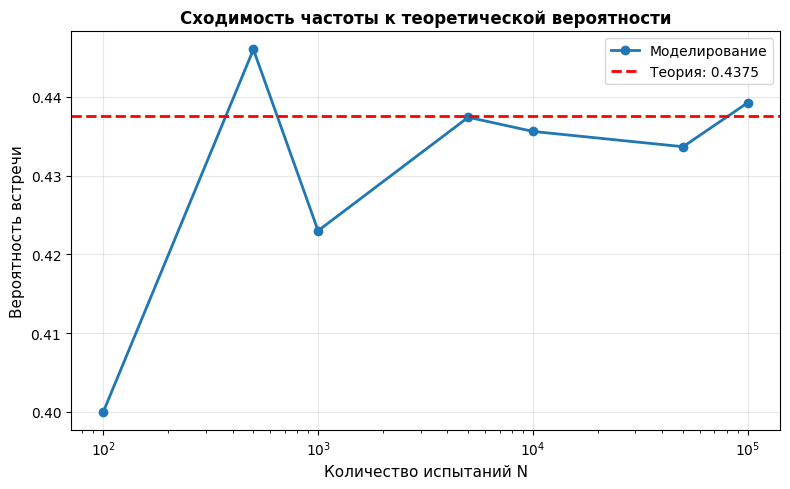

In [4]:
import matplotlib.pyplot as plt

N_values = [100, 500, 1000, 5000, 10000, 50000, 100000]
P_values = []

for N in N_values:
    np.random.seed(42)
    x = np.random.uniform(0, 60, N)
    y = np.random.uniform(0, 60, N)
    P_values.append(np.mean(np.abs(x - y) <= 15))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(N_values, P_values, 'o-', linewidth=2, markersize=6, label='Моделирование')
ax.axhline(y=P, color='red', linestyle='--', linewidth=2, label=f'Теория: {P}')
ax.set_xlabel('Количество испытаний N', fontsize=11)
ax.set_ylabel('Вероятность встречи', fontsize=11)
ax.set_title('Сходимость частоты к теоретической вероятности', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
plt.tight_layout()
plt.show()